# Section 1 — Dataset Download & Exploration

This notebook covers:
- Downloading the Chest X-Ray (Pneumonia) dataset via `kagglehub`
- Verifying file counts and directory structure
- Inspecting image properties (size distribution, channel statistics)
- Visualising sample images per class
- Analysing class distribution and the train/val/test split problem
- Saving cleaned path lists and label arrays to `artifacts/`

**Dataset:** Paul Mooney, *Chest X-Ray Images (Pneumonia)*, Kaggle  
**Labels:** `NORMAL` (0) · `PNEUMONIA` (1)  
**Total images:** 5,856 JPEG files

> ⚠️ Research prototype — **not** a medical device.

In [38]:
# ── Install dependencies ───────────────────────────────────────────────────
%pip install -q \
    torch torchvision \
    scikit-learn kagglehub tqdm Pillow

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import kagglehub
import json
from pathlib import Path
from collections import Counter
from PIL import Image
from tqdm.auto import tqdm

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

ARTIFACTS_DIR = Path('artifacts')
FIG_DIR       = Path('results/figures')
for d in [ARTIFACTS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Consistent class colours used throughout all notebooks
CLASS_COLORS = {0: '#1B4F8A', 1: '#C0392B'}   # 0=Normal, 1=Pneumonia
CLASS_NAMES  = {0: 'Normal', 1: 'Pneumonia'}

print('Imports OK')

Imports OK


## 1. Download the Dataset

Downloads the Kaggle chest X-ray dataset (~1.2 GB) and caches it locally.  
Files are cached by `kagglehub` — this only downloads once.

> **Requires:** Kaggle API credentials configured in `~/.kaggle/kaggle.json`  
> or set via `KAGGLE_USERNAME` / `KAGGLE_KEY` environment variables.

In [40]:
DATA_PATH = Path(kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia'))

# The kaggle zip unpacks with an extra nesting level — find the real root
# by locating whichever parent contains both 'train' and 'test' subdirectories
def find_dataset_root(base: Path) -> Path:
    for p in sorted(base.rglob('train')):
        if p.is_dir() and '__MACOSX' not in p.parts and (p.parent / 'test').is_dir():
            return p.parent
    raise FileNotFoundError(f'Could not find train/test under {base}')

DATA_PATH = find_dataset_root(DATA_PATH)
print(f'Dataset root: {DATA_PATH}')

# Show directory tree (top 2 levels)
for p in sorted(DATA_PATH.rglob('*')):
    depth = len(p.relative_to(DATA_PATH).parts)
    if depth <= 2:
        prefix = '  ' * (depth - 1) + ('└─ ' if depth > 1 else '')
        suffix = f'  ({len(list(p.glob("*.jpeg")))} images)' if p.is_dir() and depth == 2 else ''
        print(f'{prefix}{p.name}{suffix}')

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset root: /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray
.DS_Store
test
  └─ .DS_Store
  └─ NORMAL  (234 images)
  └─ PNEUMONIA  (390 images)
train
  └─ .DS_Store
  └─ NORMAL  (1341 images)
  └─ PNEUMONIA  (3875 images)
val
  └─ .DS_Store
  └─ NORMAL  (8 images)
  └─ PNEUMONIA  (8 images)


## 2. Verify File Counts

Cross-check against known ground-truth counts.  
A `✗` here means something went wrong with the download.

In [41]:
EXPECTED = {
    ('train', 'NORMAL'):    1341,
    ('train', 'PNEUMONIA'): 3875,
    ('val',   'NORMAL'):       8,
    ('val',   'PNEUMONIA'):    8,
    ('test',  'NORMAL'):     234,
    ('test',  'PNEUMONIA'):  390,
}

print(f'{"Split":<8} {"Class":<12} {"Found":>6}  {"Expected":>8}  Status')
print('─' * 48)
all_ok = True
for (split, cls), exp in EXPECTED.items():
    found  = len(list((DATA_PATH / split / cls).glob('*.jpeg')))
    status = '✓' if found == exp else f'✗  (expected {exp})'
    if found != exp: all_ok = False
    print(f'{split:<8} {cls:<12} {found:>6}  {exp:>8}  {status}')

print('─' * 48)
total = sum(EXPECTED.values())
print(f'{"TOTAL":<8} {"":<12} {total:>6}  {total:>8}  {"✓ all OK" if all_ok else "✗ check above"}')

Split    Class         Found  Expected  Status
────────────────────────────────────────────────
train    NORMAL         1341      1341  ✓
train    PNEUMONIA      3875      3875  ✓
val      NORMAL            8         8  ✓
val      PNEUMONIA         8         8  ✓
test     NORMAL          234       234  ✓
test     PNEUMONIA       390       390  ✓
────────────────────────────────────────────────
TOTAL                   5856      5856  ✓ all OK


## 3. Build Path Lists & Labels

Collect all image paths and integer labels into arrays.  
The original `val` split (only 16 images) will be merged with `train` and re-split 80/20 in the preprocessing notebook.

In [42]:
def collect_split(data_path: Path, split: str):
    """Return (paths, labels) for a given split directory."""
    paths, labels = [], []
    for label, cls in [(0, 'NORMAL'), (1, 'PNEUMONIA')]:
        for p in sorted((data_path / split / cls).glob('*.jpeg')):
            paths.append(p)
            labels.append(label)
    return paths, np.array(labels, dtype=np.int64)

train_paths, train_labels = collect_split(DATA_PATH, 'train')
val_paths,   val_labels   = collect_split(DATA_PATH, 'val')
test_paths,  test_labels  = collect_split(DATA_PATH, 'test')

print(f'Original splits:')
for name, paths, labels in [('train', train_paths, train_labels),
                              ('val',   val_paths,   val_labels),
                              ('test',  test_paths,  test_labels)]:
    n_normal = (labels == 0).sum()
    n_pneumo = (labels == 1).sum()
    pct_p    = 100 * n_pneumo / len(labels)
    print(f'  {name:<6}: {len(paths):5d} images  '
          f'(normal={n_normal}, pneumonia={n_pneumo}, pneumonia%={pct_p:.1f}%)')

# Save path lists as text for reference
for name, paths in [('train', train_paths), ('val', val_paths), ('test', test_paths)]:
    (ARTIFACTS_DIR / f'{name}_paths.txt').write_text('\n'.join(str(p) for p in paths))

print(f'\nPath lists saved to {ARTIFACTS_DIR}/')

Original splits:
  train :  5216 images  (normal=1341, pneumonia=3875, pneumonia%=74.3%)
  val   :    16 images  (normal=8, pneumonia=8, pneumonia%=50.0%)
  test  :   624 images  (normal=234, pneumonia=390, pneumonia%=62.5%)

Path lists saved to artifacts/


## 4. Inspect Image Properties

Chest X-rays in this dataset are not uniform in size — images come from different
scanners and have been cropped to varying dimensions. Understanding the size
distribution informs the resize strategy in Section 2.

In [43]:
# Sample 300 images from train for speed (representative enough)
rng          = np.random.default_rng(6)
sample_idx   = rng.choice(len(train_paths), size=min(300, len(train_paths)), replace=False)
sample_paths = [train_paths[i] for i in sample_idx]

widths, heights, modes = [], [], []
for p in tqdm(sample_paths, desc='Reading image headers', leave=False):
    with Image.open(p) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)
        modes.append(img.mode)

widths  = np.array(widths,  dtype=np.int32)
heights = np.array(heights, dtype=np.int32)

assert len(widths) > 0, (
    "widths array is empty — make sure cells 2–3 ran successfully "
    "and train_paths is populated before running this cell."
)

print('─' * 50)
print(f'  Image width   — min: {widths.min():5d}  max: {widths.max():5d}  mean: {widths.mean():.0f}')
print(f'  Image height  — min: {heights.min():5d}  max: {heights.max():5d}  mean: {heights.mean():.0f}')
print(f'  Aspect ratio  — mean: {(widths/heights).mean():.2f}')
print(f'  Colour modes  — {Counter(modes).most_common()}')
print('─' * 50)
print(f'  → All images will be resized to 224×224 (standard ImageNet input)')
print(f'  → RGB conversion applied to any L/RGBA images before feature extraction')

Reading image headers:   0%|          | 0/300 [00:00<?, ?it/s]

──────────────────────────────────────────────────
  Image width   — min:   400  max:  2450  mean: 1285
  Image height  — min:   138  max:  2325  mean: 932
  Aspect ratio  — mean: 1.46
  Colour modes  — [('L', 284), ('RGB', 16)]
──────────────────────────────────────────────────
  → All images will be resized to 224×224 (standard ImageNet input)
  → RGB conversion applied to any L/RGBA images before feature extraction


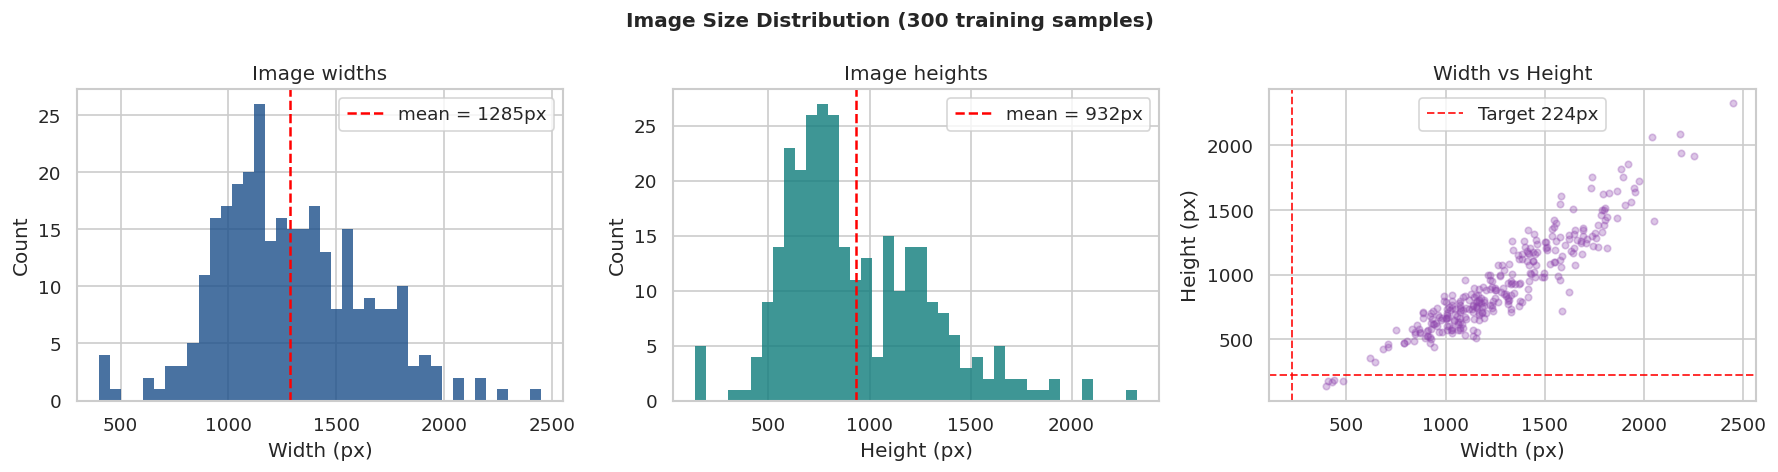

Saved → results/figures/image_size_distribution.png


In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Image Size Distribution (300 training samples)', fontsize=12, fontweight='bold')

axes[0].hist(widths,  bins=40, color='#1B4F8A', alpha=0.8, edgecolor='none')
axes[0].axvline(widths.mean(),  color='red', linestyle='--', linewidth=1.5,
                label=f'mean = {widths.mean():.0f}px')
axes[0].set_xlabel('Width (px)'); axes[0].set_ylabel('Count')
axes[0].set_title('Image widths'); axes[0].legend()

axes[1].hist(heights, bins=40, color='#0E7C7B', alpha=0.8, edgecolor='none')
axes[1].axvline(heights.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'mean = {heights.mean():.0f}px')
axes[1].set_xlabel('Height (px)'); axes[1].set_ylabel('Count')
axes[1].set_title('Image heights'); axes[1].legend()

axes[2].scatter(widths, heights, alpha=0.3, s=15, color='#8E44AD')
axes[2].axvline(224, color='red', linestyle='--', linewidth=1.2, alpha=0.8, label='Target 224px')
axes[2].axhline(224, color='red', linestyle='--', linewidth=1.2, alpha=0.8)
axes[2].set_xlabel('Width (px)'); axes[2].set_ylabel('Height (px)')
axes[2].set_title('Width vs Height'); axes[2].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'image_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/figures/image_size_distribution.png')

## 5. Visualise Sample Images per Class

Display 4 representative images per class from the training set.  
Key visual differences to note:
- **Normal**: clear lung fields, visible vascular markings
- **Pneumonia**: opacification (white haziness), consolidation regions

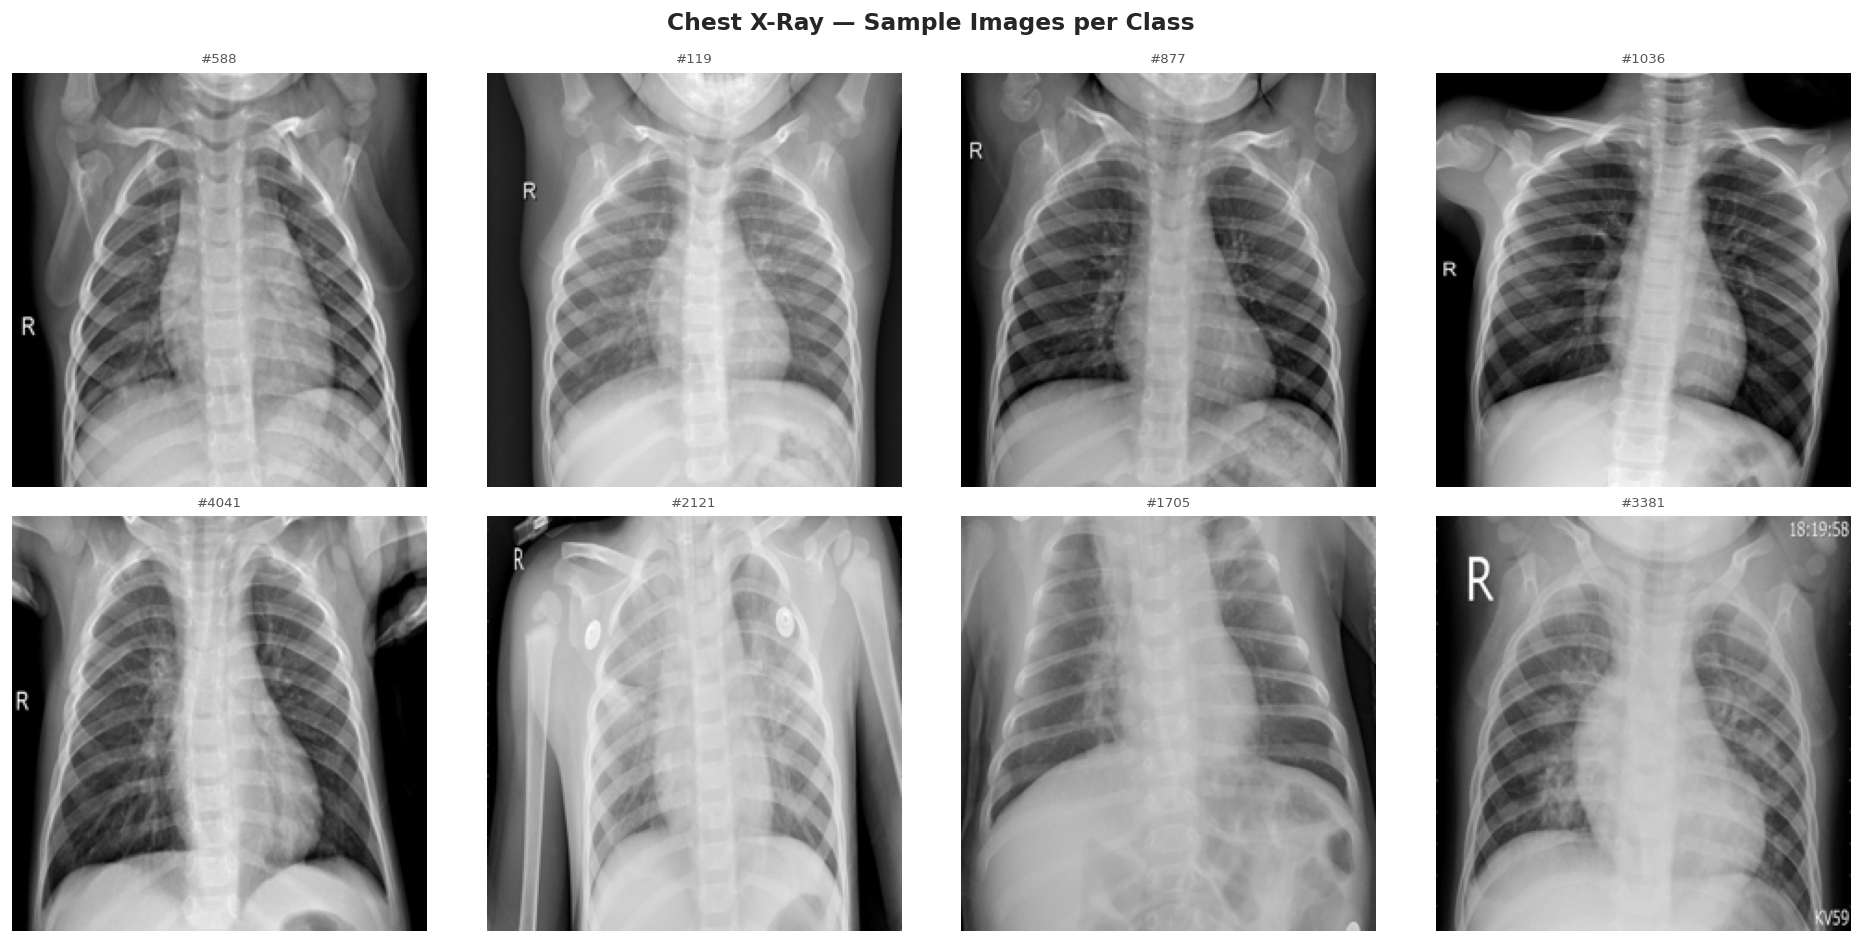

Saved → results/figures/sample_images.png


In [45]:
N_SAMPLES = 4
rng_vis   = np.random.default_rng(42)

fig, axes = plt.subplots(2, N_SAMPLES, figsize=(16, 8))
fig.suptitle('Chest X-Ray — Sample Images per Class', fontsize=14, fontweight='bold')

for cls_int, cls_name in CLASS_NAMES.items():
    cls_idx = np.where(train_labels == cls_int)[0]
    chosen  = rng_vis.choice(cls_idx, size=N_SAMPLES, replace=False)
    color   = CLASS_COLORS[cls_int]

    for col, img_idx in enumerate(chosen):
        ax  = axes[cls_int][col]
        img = Image.open(train_paths[img_idx]).convert('RGB').resize((224, 224))
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(cls_name, fontsize=12, color=color, fontweight='bold')
            ax.yaxis.set_visible(True)
            ax.tick_params(left=False, labelleft=False)
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(2.5)
                spine.set_visible(True)
        ax.set_title(f'#{img_idx}', fontsize=8, color='#555555')

plt.tight_layout()
plt.savefig(FIG_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/figures/sample_images.png')

## 6. Class Distribution

The dataset is **severely imbalanced**: pneumonia cases outnumber normal by ~2.9:1 in training.  
This motivates the use of `WeightedRandomSampler` and weighted loss functions.

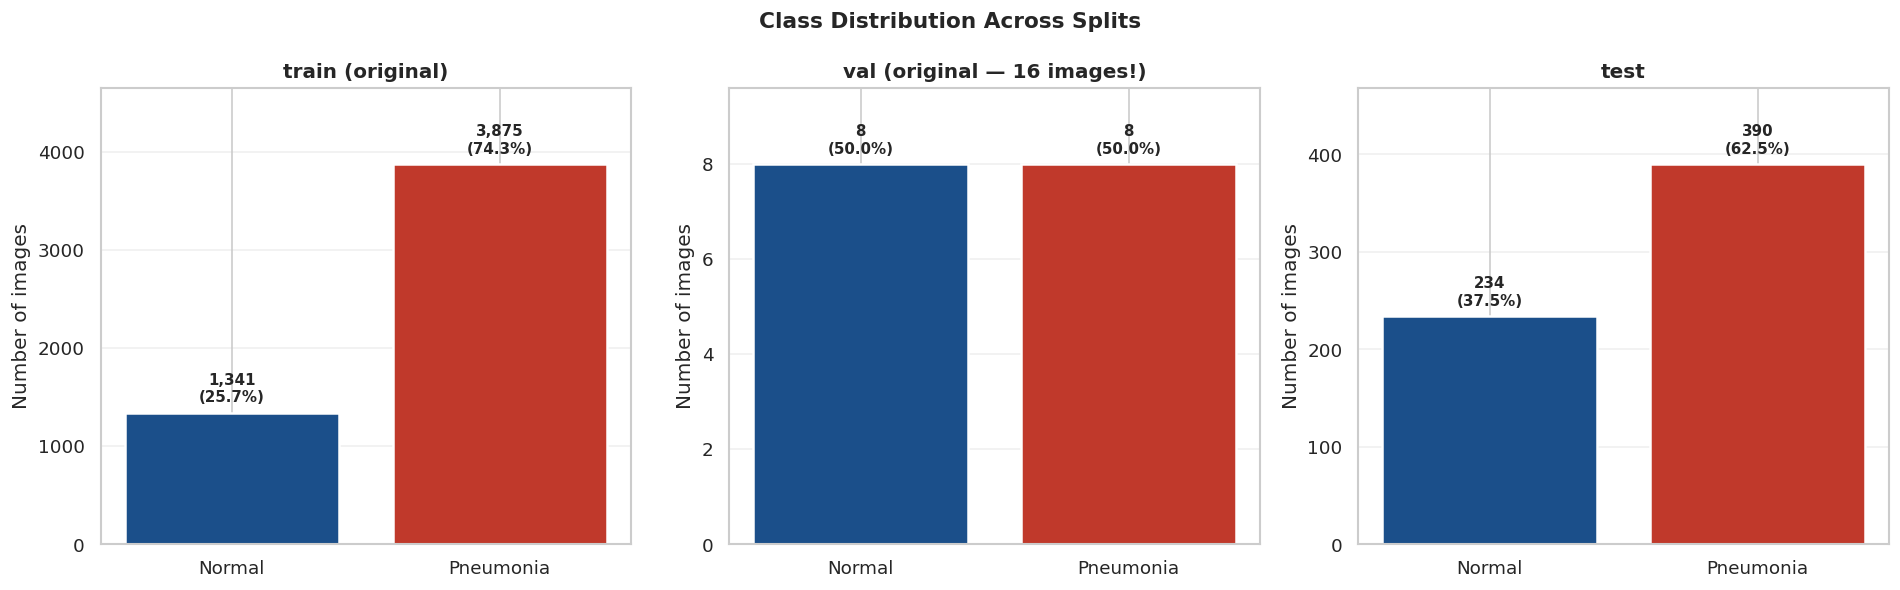

Saved → results/figures/class_distribution.png

⚠️  Validation set problem:
   Original val set has only 16 images — statistically insufficient.
   Fix: merge train+val, re-split 80/20 stratified → 4185/1046


In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Class Distribution Across Splits', fontsize=13, fontweight='bold')

split_data = [
    ('train (original)', train_labels),
    ('val (original — 16 images!)', val_labels),
    ('test', test_labels),
]

for ax, (split_name, labels) in zip(axes, split_data):
    counts = [int((labels == c).sum()) for c in [0, 1]]
    colors = [CLASS_COLORS[0], CLASS_COLORS[1]]
    bars   = ax.bar(CLASS_NAMES.values(), counts, color=colors,
                    edgecolor='white', linewidth=1.5)

    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.02,
                f'{count:,}\n({100*count/sum(counts):.1f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_ylabel('Number of images')
    ax.set_title(split_name, fontweight='bold')
    ax.set_ylim(0, max(counts) * 1.20)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/figures/class_distribution.png')

# Print the validation problem clearly
print()
print('⚠️  Validation set problem:')
print(f'   Original val set has only {len(val_labels)} images — statistically insufficient.')
n_all = len(train_labels) + len(val_labels)
print(f'   Fix: merge train+val, re-split 80/20 stratified → {int(n_all * 0.8)}/{int(n_all * 0.2)}')

## 7. Pixel Intensity Statistics per Class

Compute per-channel mean and std across a sample of images.  
These values confirm the ImageNet normalisation constants are appropriate —
and reveal the visual signature difference between classes.

In [47]:
# Sample 200 images per class for speed
N_STAT = 200
rng_stat = np.random.default_rng(6)

class_pixel_means = {}
class_pixel_stds  = {}

for cls_int, cls_name in CLASS_NAMES.items():
    cls_idx  = np.where(train_labels == cls_int)[0]
    chosen   = rng_stat.choice(cls_idx, size=min(N_STAT, len(cls_idx)), replace=False)
    pixels   = []
    for i in tqdm(chosen, desc=f'{cls_name} pixel stats', leave=False):
        img = np.array(Image.open(train_paths[i]).convert('L').resize((224, 224)),
                       dtype=np.float32) / 255.0
        pixels.append(img.flatten())
    flat = np.concatenate(pixels)
    class_pixel_means[cls_int] = float(flat.mean())
    class_pixel_stds[cls_int]  = float(flat.std())
    print(f'  {cls_name:<12}: mean={flat.mean():.4f}  std={flat.std():.4f}')

print()
print('ImageNet grayscale normalisation: mean≈0.449, std≈0.226')
print('→ Dataset pixel statistics are close enough to use ImageNet statistics.')

Normal pixel stats:   0%|          | 0/200 [00:00<?, ?it/s]

  Normal      : mean=0.4822  std=0.2470


Pneumonia pixel stats:   0%|          | 0/200 [00:00<?, ?it/s]

  Pneumonia   : mean=0.4745  std=0.2312

ImageNet grayscale normalisation: mean≈0.449, std≈0.226
→ Dataset pixel statistics are close enough to use ImageNet statistics.


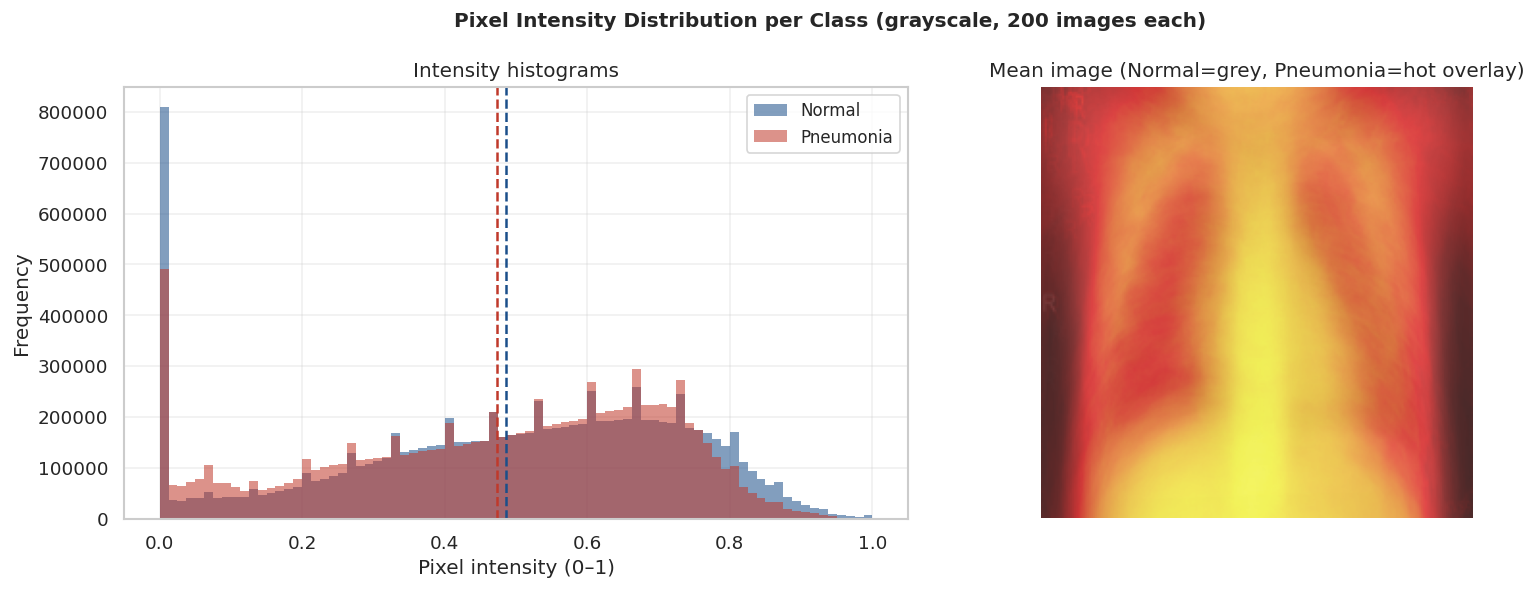

Saved → results/figures/pixel_intensity_distribution.png


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pixel Intensity Distribution per Class (grayscale, 200 images each)',
             fontsize=12, fontweight='bold')

for cls_int, cls_name in CLASS_NAMES.items():
    cls_idx = np.where(train_labels == cls_int)[0]
    chosen  = rng_stat.choice(cls_idx, size=min(N_STAT, len(cls_idx)), replace=False)
    pixels  = []
    for i in chosen:
        img = np.array(Image.open(train_paths[i]).convert('L').resize((224, 224)),
                       dtype=np.float32) / 255.0
        pixels.append(img.flatten())
    flat  = np.concatenate(pixels)
    color = CLASS_COLORS[cls_int]

    axes[0].hist(flat, bins=80, color=color, alpha=0.55, edgecolor='none', label=cls_name)
    axes[0].axvline(flat.mean(), color=color, linestyle='--', linewidth=1.5)

    # Mean image heatmap
    mean_imgs = []
    for i in rng_stat.choice(cls_idx, size=min(50, len(cls_idx)), replace=False):
        mean_imgs.append(np.array(Image.open(train_paths[i]).convert('L').resize((224, 224)),
                                  dtype=np.float32) / 255.0)
    mean_img = np.mean(mean_imgs, axis=0)
    im = axes[1].imshow(mean_img, cmap='gray' if cls_int == 0 else 'hot',
                        alpha=0.6, vmin=0, vmax=1)

axes[0].set_xlabel('Pixel intensity (0–1)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Intensity histograms')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Mean image (Normal=grey, Pneumonia=hot overlay)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(FIG_DIR / 'pixel_intensity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/figures/pixel_intensity_distribution.png')

## 8. Visualise the Val Split Problem

The original validation set has only **16 images** — 8 per class.
At this size, any AUC or accuracy figure is dominated by random chance.
The plot below illustrates how the 80/20 re-split corrects this.

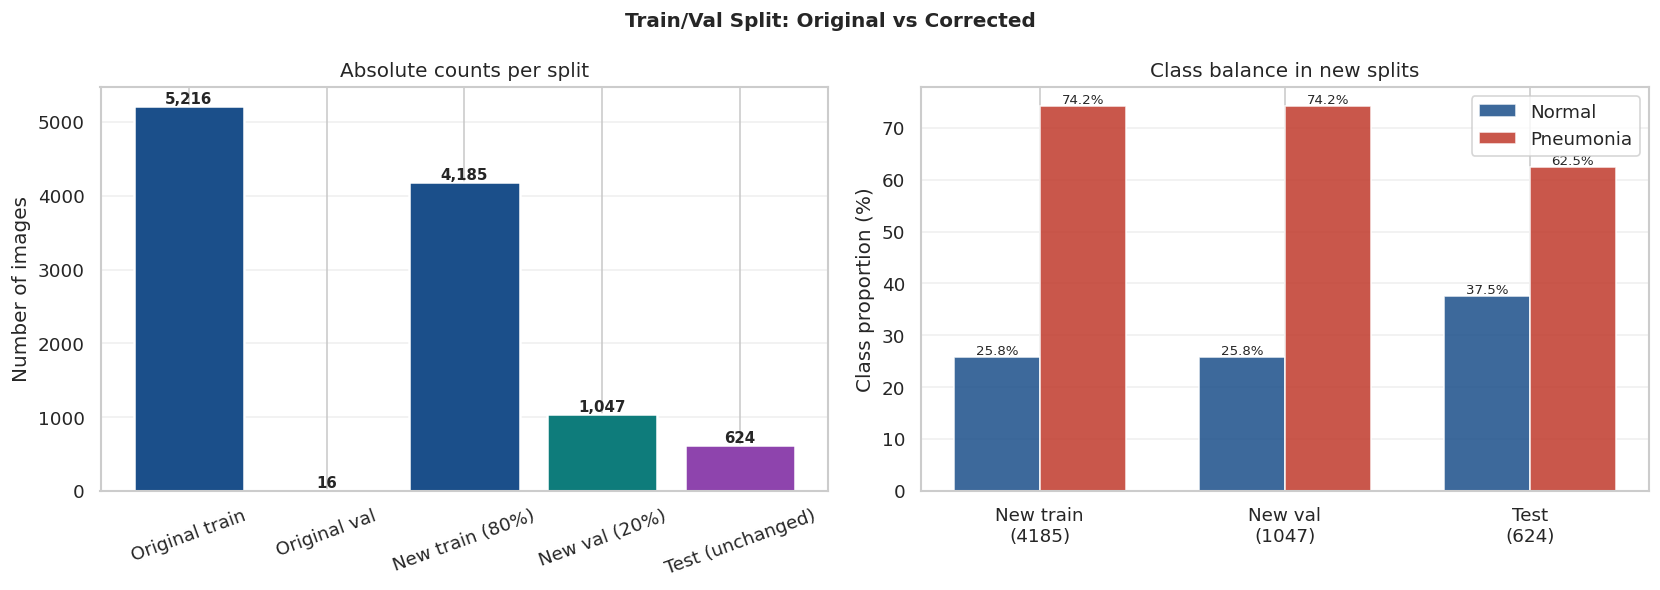

Saved → results/figures/split_comparison.png

New split summary:
  New train :  4185  (pneumonia: 3106, normal: 1079)
  New val   :  1047  (pneumonia: 777, normal: 270)
  Test      :   624  (pneumonia: 390, normal: 234)


In [49]:
from sklearn.model_selection import train_test_split

all_paths  = train_paths + val_paths
all_labels = np.concatenate([train_labels, val_labels])

new_train_p, new_val_p, new_train_l, new_val_l = train_test_split(
    all_paths, all_labels, test_size=0.20, stratify=all_labels, random_state=6
)

split_comparison = {
    'Original train':  len(train_paths),
    'Original val':    len(val_paths),
    'New train (80%)': len(new_train_p),
    'New val (20%)':   len(new_val_p),
    'Test (unchanged)': len(test_paths),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Train/Val Split: Original vs Corrected', fontsize=12, fontweight='bold')

# Left: absolute counts
colors_bar = ['#1B4F8A', '#C0392B', '#1B4F8A', '#0E7C7B', '#8E44AD']
bars = axes[0].bar(split_comparison.keys(), split_comparison.values(),
                   color=colors_bar, edgecolor='white', linewidth=1.5)
for bar, (name, count) in zip(bars, split_comparison.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{count:,}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylabel('Number of images')
axes[0].set_title('Absolute counts per split')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(True, axis='y', alpha=0.3)

# Right: class balance in new splits
for ax, (name, labels_arr) in zip(
    [axes[1]], [('New train + New val', np.concatenate([new_train_l, new_val_l]))]):
    pass  # just show new splits side by side

new_splits = [
    ('New train\n(4185)', new_train_l),
    ('New val\n(1047)',   new_val_l),
    ('Test\n(624)',       test_labels),
]
x = np.arange(len(new_splits))
w = 0.35
for cls_int, cls_name in CLASS_NAMES.items():
    pcts = [100 * (ls == cls_int).mean() for _, ls in new_splits]
    axes[1].bar(x + cls_int*w - w/2, pcts, w, label=cls_name,
                color=CLASS_COLORS[cls_int], alpha=0.85, edgecolor='white')
    for xi, pct in zip(x + cls_int*w - w/2, pcts):
        axes[1].text(xi, pct + 0.5, f'{pct:.1f}%', ha='center', fontsize=8)

axes[1].set_xticks(x)
axes[1].set_xticklabels([s for s, _ in new_splits])
axes[1].set_ylabel('Class proportion (%)')
axes[1].set_title('Class balance in new splits')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'split_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/figures/split_comparison.png')

print()
print('New split summary:')
print(f'  New train : {len(new_train_p):5d}  (pneumonia: {new_train_l.sum()}, normal: {(new_train_l==0).sum()})')
print(f'  New val   : {len(new_val_p):5d}  (pneumonia: {new_val_l.sum()}, normal: {(new_val_l==0).sum()})')
print(f'  Test      : {len(test_paths):5d}  (pneumonia: {test_labels.sum()}, normal: {(test_labels==0).sum()})')

## 9. Pneumonia Subtypes

Pneumonia cases in this dataset include both bacterial and viral subtypes.
These are not separately labelled in the binary task, but understanding their
visual differences is useful for thesis context and Grad-CAM interpretation.

Pneumonia subtype breakdown (training set):
  Bacterial :  2530  (65.3%)
  Viral     :  1345  (34.7%)
  Unknown   :     0

Note: The quantum classifier treats all pneumonia as one class.
Subtype breakdown is reported here for thesis context only.


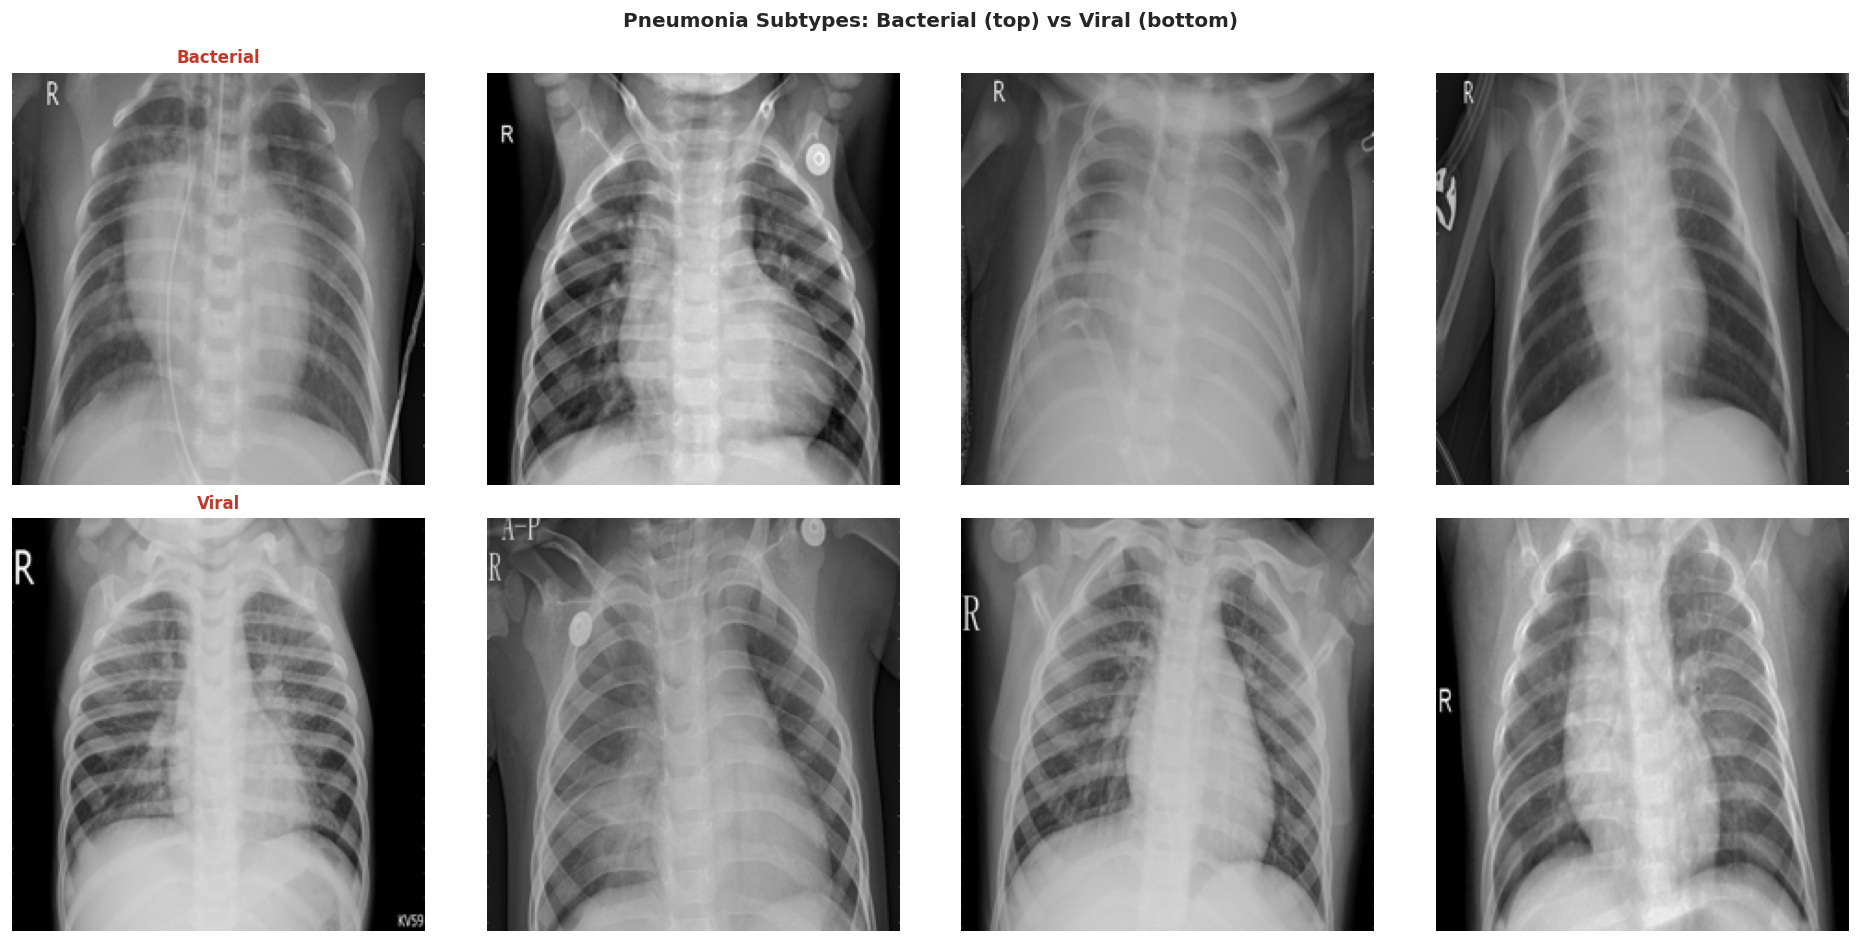

Saved → results/figures/pneumonia_subtypes.png


In [50]:
# Identify bacterial vs viral from filename convention (BACTERIA / VIRUS in path)
pneumonia_paths = [p for p, l in zip(train_paths, train_labels) if l == 1]

bacterial = [p for p in pneumonia_paths if 'bacteria' in str(p).lower()]
viral     = [p for p in pneumonia_paths if 'virus'    in str(p).lower()]
other     = [p for p in pneumonia_paths if p not in bacterial and p not in viral]

print('Pneumonia subtype breakdown (training set):')
print(f'  Bacterial : {len(bacterial):5d}  ({100*len(bacterial)/len(pneumonia_paths):.1f}%)')
print(f'  Viral     : {len(viral):5d}  ({100*len(viral)/len(pneumonia_paths):.1f}%)')
print(f'  Unknown   : {len(other):5d}')
print()
print('Note: The quantum classifier treats all pneumonia as one class.')
print('Subtype breakdown is reported here for thesis context only.')

# Show 2 examples of each
rng_sub = np.random.default_rng(99)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Pneumonia Subtypes: Bacterial (top) vs Viral (bottom)', fontsize=12, fontweight='bold')

for row, (subtype_paths, label) in enumerate([(bacterial, 'Bacterial'), (viral, 'Viral')]):
    chosen = rng_sub.choice(len(subtype_paths), size=4, replace=False)
    for col, idx in enumerate(chosen):
        ax  = axes[row][col]
        img = Image.open(subtype_paths[idx]).convert('RGB').resize((224, 224))
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_title(f'{label}', fontsize=10, fontweight='bold',
                         color='#C0392B', pad=6)

plt.tight_layout()
plt.savefig(FIG_DIR / 'pneumonia_subtypes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/figures/pneumonia_subtypes.png')

## 10. Summary — Ready for Section 2

| Check | Status |
|---|---|
| Dataset downloaded and verified (5,856 images) | ✅ |
| File counts match expected values | ✅ |
| Image size distribution inspected | ✅ |
| Sample images visualised per class | ✅ |
| Class imbalance documented (~74% pneumonia in train) | ✅ |
| Val split problem identified (16 images) | ✅ |
| 80/20 re-split verified (4185 / 1047) | ✅ |
| Pixel intensity statistics computed | ✅ |
| Pneumonia subtype breakdown reported | ✅ |
| Path lists saved to `artifacts/` | ✅ |

**Next step:** `02_preprocessing.ipynb` — RandAugment transforms, WeightedRandomSampler,
ResNet-50 and EfficientNet-B0 feature extraction, PCA(64) pipeline.

In [51]:
print('Section 1 complete.')
print(f'  Total images   : {sum(EXPECTED.values()):,}')
print(f'  Classes        : Normal (0), Pneumonia (1)')
print(f'  Imbalance ratio: 1 : {(train_labels==1).sum() / (train_labels==0).sum():.1f}  (normal : pneumonia)')
print(f'  Saved to       : {FIG_DIR}/')

Section 1 complete.
  Total images   : 5,856
  Classes        : Normal (0), Pneumonia (1)
  Imbalance ratio: 1 : 2.9  (normal : pneumonia)
  Saved to       : results/figures/
